# ***Challenge:*** Conversión de grados Celsius a Fahrenheit.

Dados los siguientes datos:

<div class="instructions"><div class="inner">
<div class="devsite-table-wrapper">
  <table class="vertical-rules">
    <tbody>
      <tr>
        <td colspan="1" rowspan="1"><p>Celsius:</p></td>
        <td colspan="1" rowspan="1"><p>-40.0</p></td>
        <td colspan="1" rowspan="1"><p>-10.0</p></td>
        <td colspan="1" rowspan="1"><p>0.0</p></td>
        <td colspan="1" rowspan="1"><p>8.0</p></td>
        <td colspan="1" rowspan="1"><p>15.0</p></td>
        <td colspan="1" rowspan="1"><p>22.0</p></td>
        <td colspan="1" rowspan="1"><p>38.0</p></td>
      </tr>
      <tr>
        <td colspan="1" rowspan="1"><p>Fahrenheit:</p></td>
        <td colspan="1" rowspan="1"><p>-40.0</p></td>
        <td colspan="1" rowspan="1"><p>14.0</p></td>
        <td colspan="1" rowspan="1"><p>32.0</p></td>
        <td colspan="1" rowspan="1"><p>46.0</p></td>
        <td colspan="1" rowspan="1"><p>59.0</p></td>
        <td colspan="1" rowspan="1"><p>72.0</p></td>
        <td colspan="1" rowspan="1"><p>100.0</p></td>
      </tr>
    </tbody>
  </table>
</div>
</div></div>

Visualice los datos a través de un gráfico para analizar el comportamiento de una regresión lineal con los datos en **Celsius** y **Fahrenheit**.

$Recordando$ $la$ $ecuación$ $para$ $la$ $conversión$ $de$ $grados$ $Celcius$ $a$ $Fahrenheit:$

$
F° = C°*1.8 + 32
$

Entrene una red neuronal para predecir los datos siguientes, recordando que, la infraestructura de prueba, espera un modelo entrenado que acepte una forma de entrada de [1].

Realice un test de entrenamiento para verificar las epocas dadas y visualice el comportamiento de las perdidas según el algoritmo utilizado.  

Guarde el modelo anterior en un archivo con el nombre y tipo de dato **mymodel.h5**

## 1. Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


## 2. Datos

In [2]:
celsius    = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)
for c, f in zip(celsius, fahrenheit):
    print(f"{c:>6.1f} C = {f:>6.1f} F")

 -40.0 C =  -40.0 F
 -10.0 C =   14.0 F
   0.0 C =   32.0 F
   8.0 C =   46.0 F
  15.0 C =   59.0 F
  22.0 C =   72.0 F
  38.0 C =  100.0 F


## 3. Analisis visual

La relacion teorica es $F = 1.8 \cdot C + 32$: una recta. Visualizamos los datos
junto a esa recta para confirmar el comportamiento lineal.

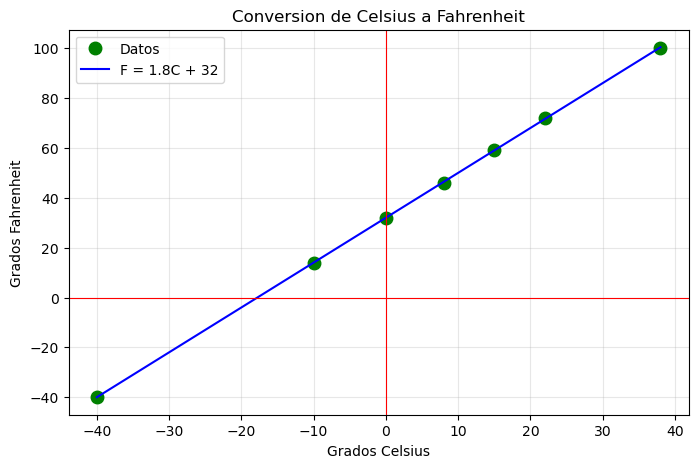

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(celsius, fahrenheit, "o", color="green", markersize=9, label="Datos")
plt.plot(celsius, 1.8 * celsius + 32, color="blue", label="F = 1.8C + 32")
plt.axhline(y=0, color="red", lw=0.8); plt.axvline(x=0, color="red", lw=0.8)
plt.title("Conversion de Celsius a Fahrenheit")
plt.xlabel("Grados Celsius"); plt.ylabel("Grados Fahrenheit")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4. Red neuronal

Entrenamos una red con una entrada de forma `[1]`. Usamos el optimizador **Adam**
con una tasa de aprendizaje de 0.1 (converge mas rapido que `sgd` en este
problema) y `mse` como funcion de perdida.

In [4]:
capa = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([tf.keras.Input(shape=(1,)), capa])
modelo.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss="mean_squared_error")
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
historial = modelo.fit(celsius, fahrenheit, epochs=500, verbose=0)

## 5. Comportamiento de la perdida

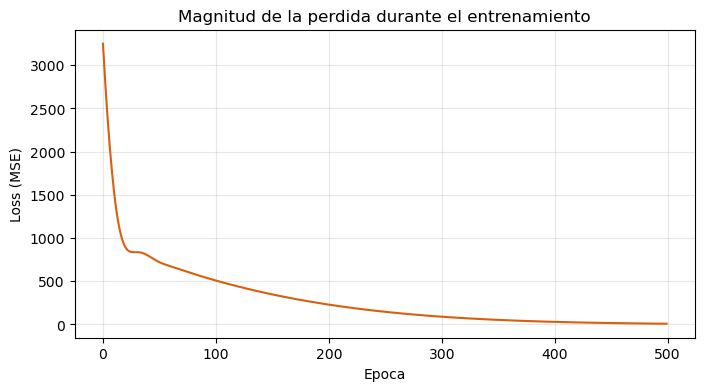

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"], color="#d95f0e")
plt.title("Magnitud de la perdida durante el entrenamiento")
plt.xlabel("Epoca"); plt.ylabel("Loss (MSE)"); plt.grid(alpha=0.3); plt.show()

## 6. Prediccion y verificacion

Probamos con 100 C (esperado: 212 F) y comprobamos que los pesos aprendidos se
aproximan a la formula real: pendiente ~ 1.8 y ordenada ~ 32.

In [7]:
valor = 100.0
pred = modelo.predict(np.array([[valor]]), verbose=0)[0, 0]
print(f"Prediccion para {valor} C: {pred:.2f} F  (esperado: {1.8*valor + 32:.2f} F)")

w, b = capa.get_weights()
print(f"\nPeso (pendiente): {w[0,0]:.4f}  (real: 1.8)")
print(f"Sesgo (ordenada): {b[0]:.4f}  (real: 32)")

Prediccion para 100.0 C: 211.32 F  (esperado: 212.00 F)

Peso (pendiente): 1.8231  (real: 1.8)
Sesgo (ordenada): 29.0137  (real: 32)


## 7. Guardar el modelo

In [8]:
modelo.save("mymodel.h5")
print("Modelo guardado en mymodel.h5")

Modelo guardado en mymodel.h5



La red aprende practicamente la formula exacta de conversion: la neurona lineal recupera la pendiente (1.8) y la ordenada (32).